In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.pipeline import Pipeline 
# membaca data 
df = pd.read_csv("agri_shrinkage_train.csv") 
print(df.head()) 
print(df.describe())

     rainfall   humidity  temperature  soil_moisture  irrigation  \
0  164.901425  88.166008    28.852355      90.824072  100.990332   
1  145.852071  93.344931    30.818833      82.954761   93.869505   
2  169.430656  95.000000    24.202865      93.844643   80.894456   
3  195.690896  95.000000    28.125938     100.000000   70.295948   
4  142.975399  80.295770    25.698715      80.401117   90.473350   

   fertilizer_a  fertilizer_b  sunlight_intensity   soil_ph  pest_index  \
0    126.617605    126.843447          241.870708  5.929929    3.846941   
1    136.670579    133.734679          377.115013  6.142193    5.813386   
2     80.125287     79.482625          323.836973  5.883032    2.258589   
3    127.481131    126.100326          276.774684  6.076815    3.985493   
4    144.553380    141.985342          370.448104  5.442554    2.497128   

       yield  
0  24.339198  
1  26.137678  
2  11.871273  
3  20.551849  
4  21.220025  
         rainfall    humidity  temperature  soil_m

In [2]:
X = df.drop(columns=["yield"]) 
y = df["yield"] 
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.3, random_state=42 
)

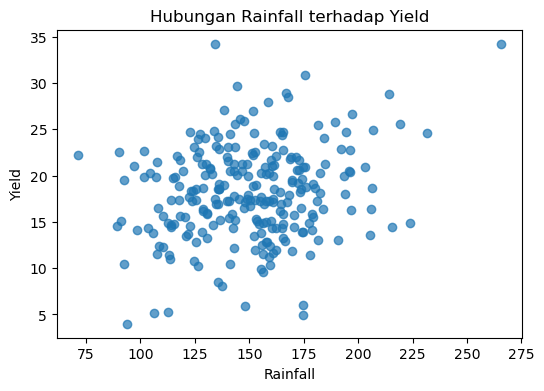

In [3]:
plt.figure(figsize=(6,4)) 
plt.scatter(df["rainfall"], df["yield"], alpha=0.7) 
plt.xlabel("Rainfall") 
plt.ylabel("Yield") 
plt.title("Hubungan Rainfall terhadap Yield") 
plt.show()


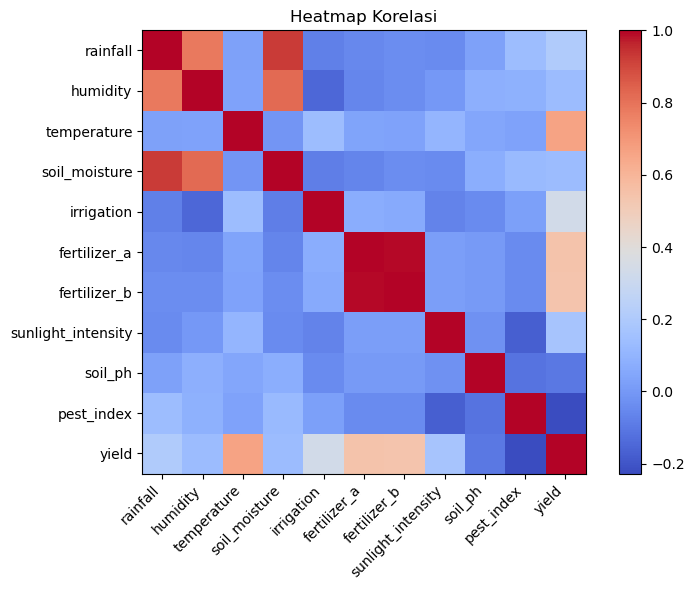

In [7]:
corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Heatmap Korelasi")
plt.tight_layout()
plt.show()

In [9]:
ols_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ols_model.fit(X_train, y_train)

y_pred_train_ols = ols_model.predict(X_train)
y_pred_test_ols = ols_model.predict(X_test)

rmse_train_ols = np.sqrt(mean_squared_error(y_train, y_pred_train_ols))
rmse_test_ols = np.sqrt(mean_squared_error(y_test, y_pred_test_ols))

r2_train_ols = r2_score(y_train, y_pred_train_ols)
r2_test_ols = r2_score(y_test, y_pred_test_ols)

print("OLS Train RMSE:", rmse_train_ols)
print("OLS Test RMSE :", rmse_test_ols)

print("OLS Train R2 :", r2_train_ols)
print("OLS Test R2 :", r2_test_ols)

coef_ols = ols_model.named_steps["model"].coef_

print("Koefisien OLS:", coef_ols)

OLS Train RMSE: 1.5303978430555065
OLS Test RMSE : 1.3882559748075445
OLS Train R2 : 0.9052198828822228
OLS Test R2 : 0.9261067913065398
Koefisien OLS: [ 2.28122011 -0.09933998  2.86331003 -0.90516941  1.23520123  1.20092633
  1.26978926  0.40073291 -0.72718195 -1.43304743]


In [11]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.08, max_iter=20000))
])

lasso_model.fit(X_train, y_train)

y_pred_train_lasso = lasso_model.predict(X_train)
y_pred_test_lasso = lasso_model.predict(X_test)

rmse_train_lasso = np.sqrt(
    mean_squared_error(y_train, y_pred_train_lasso)
)

rmse_test_lasso = np.sqrt(
    mean_squared_error(y_test, y_pred_test_lasso)
)

r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

print("Lasso Train RMSE:", rmse_train_lasso)
print("Lasso Test RMSE :", rmse_test_lasso)

print("Lasso Train R2 :", r2_train_lasso)
print("Lasso Test R2 :", r2_test_lasso)

coef_lasso = lasso_model.named_steps["model"].coef_

print("Koefisien Lasso:", coef_lasso)


Lasso Train RMSE: 1.588277239147155
Lasso Test RMSE : 1.3377821526060358
Lasso Train R2 : 0.8979151780351797
Lasso Test R2 : 0.9313822902725097
Koefisien Lasso: [ 1.28147841 -0.          2.82000133 -0.          1.17859724  1.91719868
  0.48717175  0.35204012 -0.70391729 -1.34422124]


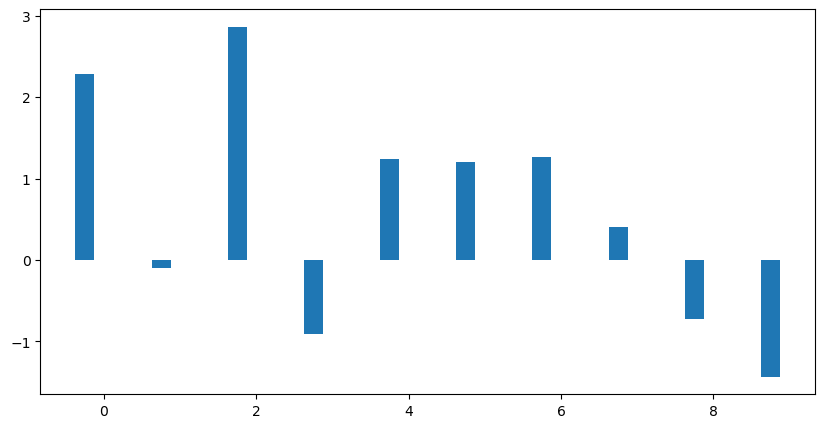

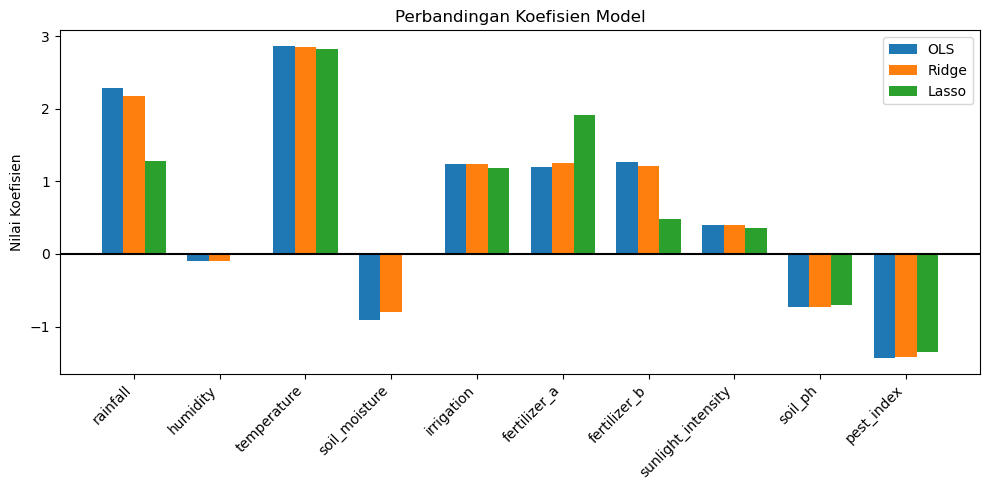

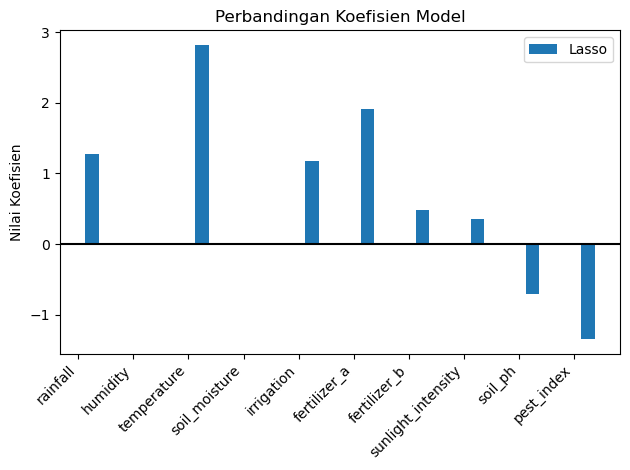

In [13]:
features = X.columns

plt.figure(figsize=(10,5))

x = np.arange(len(features))
width = 0.25

plt.bar(x - width, coef_ols, width, label="OLS")
features = X.columns

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
coef_ridge = ridge_model.named_steps["model"].coef_

plt.figure(figsize=(10,5))

x = np.arange(len(features))
width = 0.25

plt.bar(x - width, coef_ols, width, label="OLS")
plt.bar(x, coef_ridge, width, label="Ridge")
plt.bar(x + width, coef_lasso, width, label="Lasso")

plt.axhline(0, color="black")

plt.xticks(x, features, rotation=45, ha="right")

plt.ylabel("Nilai Koefisien")
plt.title("Perbandingan Koefisien Model")

plt.legend()

plt.tight_layout()
plt.show()
plt.bar(x + width, coef_lasso, width, label="Lasso")

plt.axhline(0, color="black")

plt.xticks(x, features, rotation=45, ha="right")

plt.ylabel("Nilai Koefisien")
plt.title("Perbandingan Koefisien Model")

plt.legend()

plt.tight_layout()
plt.show()

## Pertanyaan Fundamental 
Mahasiswa diminta menjawab pertanyaan berikut selama atau setelah praktikum: 6

### 1. Apa yang menjadi target prediksi pada use case ini?
Target prediksi pada use case ini adalah hasil panen padi (yield)
### 2. Mengapa kasus hasil panen padi termasuk masalah regresi? 
Karena berupa nilai numerik dan sifatnya kontinu yang dapat dihitung
### 3. Apa makna koefisien positif dan negatif dalam model regresi? 
Positif = Jika nilai fitur meningkat, maka hasil prediksi yield juga cendrung meningkat
Negatif = Jika nilai fitur meningkat, maka hasil prediksi yield cenderung menurun
### 4. Mengapa kita tidak cukup hanya melihat nilai prediksi tanpa memahami struktur data? 
Karena struktur data dapat mempengaruhi kualitas model
### 5. Apa yang dimaksud dengan multikolinearitas? 
Multikolinearitas adalah ondisi ketika beberapa fitur saling berkorelasi kuat satu sama lain
### 6. Mengapa multikolinearitas dapat menimbulkan masalah bagi OLS?
Karena sulit menentukan pengaruh masing-masing fitur secara jelas jika fitur tersebut mirip
### 7. Mengapa OLS tetap penting dipelajari meskipun memiliki kelemahan? 
Karena dasar dari banyak metode regresi lainnya
### 8. Apa ide utama shrinkage dalam Ridge dan Lasso? 
Memberikan penalti atau nilai toleransi oada besar koefisien agar model lebih stabil, tidak terlalu sensitif dan tidak overfitting
### 9. Apa perbedaan utama Ridge dan Lasso dari sisi perilaku koefisien? 
Ridge = mengecilkan semua koefisien secara bertahap dan jarang membuatnya menjadi 0
Lasso = mengecilkan koefisien dan dapat membautnya menjadi 0 dan secara otomatis menghapus fitur yang kurang penting
### 10. Mengapa Lasso sering dikaitkan dengan feature selection? 
Karean dapat membuat beberapa koefisien menjadi 0

## Pertanyaan Analisis 
Mahasiswa juga diminta melakukan analisis terhadap hasil eksperimen: 

### 1. Dari heatmap korelasi, fitur mana yang tampak saling berkorelasi? 
rainfall
humidity,
soil_moisture,
fertilizer_A dengan fertilizer_B.
### 2. Apakah koefisien OLS tampak stabil dan mudah diinterpretasikan? 
tidak selalu stabil ketika terdapat multikolinearitas sehingga akan sulit dibandingkan dengan Ridge dan Lasso
### 3. Bandingkan besar koefisien OLS dan Ridge. Apa yang berubah?
Ridge 
- Nilai koefisien menajdi lebih kecil
- Lebih stabil
- Tidak terlalu eksrem
### 4. Apakah ada koefisien Lasso yang menjadi nol atau sangat kecil? Apa artinya? 
Ada, terdapat pada beberapa koefisien yang menajdi sangat kecil bahkan hingga 0. Artinya fitur di anggap tidak penting sehingga kontribusinya di hilangkan.
### 5. Model mana yang memberikan performa terbaik pada data uji berdasarkan RMSE dan R2? 
Model yang terbaik adalah yang meiliki RMSE yang kecil dan R² yang paling besar, sehingga Ridge yang lebih baik
### 6. Jika tujuan utama adalah stabilitas prediksi, model mana yang lebih masuk akal? 
Ridge, karena lebih stabil terhadap multikolinearitas dan koefisien yang tidak terlalu ekstrem
### 7. Jika tujuan utama adalah menyederhanakan model, model mana yang lebih tepat? 
Lasso, karena dapat menghilangkan fitur yang tidak berpengaruh secara signifikan sehingga menghasilkan model yang lebih sederhana
### 8. Apakah model dengan error terkecil selalu menjadi model terbaik untuk dipilih? Jelaskan.
Tidak, selain Error ada hal yang harus di pertimbangkan seperti, Stabilitas dari model, Interpretasinya, dan kompleksitas model itu sendiri 
Tugas Singkat di Akhir Praktikum 
Sebagai penutup, mahasiswa diminta menuliskan refleksi singkat (1–2 paragraf) menge nai: 
• pelajaran utama yang diperoleh dari perbandingan OLS, Ridge, dan Lasso; • alasan mengapa shrinkage penting dalam sains data; 
• model mana yang menurut mereka paling sesuai untuk use case hasil panen padi dan alasannya. 

## Luaran Praktikum 
Pada akhir sesi, mahasiswa diharapkan menghasilkan: 
1. notebook atau file Python yang dapat dijalankan; 
2. visualisasi dasar: scatter plot, heatmap korelasi, dan perbandingan koefisien; 3. jawaban atas pertanyaan fundamental dan analisis; 
4. refleksi singkat mengenai hasil praktikum. 
Penutup 
Praktikum ini menekankan bahwa pemodelan tidak berhenti pada “membangun model”. Mahasiswa perlu memahami konteks masalah, mengenali keterbatasan model dasar seper ti OLS, dan memahami kapan metode seperti Ridge dan Lasso menjadi penting. Dengan demikian, mahasiswa tidak hanya belajar menjalankan algoritma, tetapi juga belajar berpikir sebagai seorang analis data.
